In [2]:
import os
os.getcwd()

'C:\\Users\\PC'

In [3]:
os.chdir(r"D:\FQL\PJ 6")

## Section 1 : Import Necessary Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

In [5]:
pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [7]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)
from sklearn.inspection import permutation_importance

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3250', 'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
    'text.color': '#c9d1d9', 'grid.color': '#21262d',
    'grid.linestyle': '--', 'font.family': 'monospace',
    'axes.titlesize': 13, 'axes.labelsize': 11,
})
PALETTE = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657', '#79c0ff']

os.makedirs('plots', exist_ok=True)
print('Libraries loaded ')

Libraries loaded 


## Section 2 : Load Saved Artifiacts

In [8]:
# Load from Notebook 2 
best_model    = joblib.load('models/best_model.pkl')
all_models    = joblib.load('models/all_tuned_models.pkl')
split_data    = joblib.load('models/split_data.pkl')
eval_df       = pd.read_csv('models/test_predictions.csv', parse_dates=['Datetime'])
all_preds_df  = pd.read_csv('models/all_model_predictions.csv', parse_dates=['Datetime'])
FEATURES      = split_data['features']
best_name     = split_data['best_model_name']

X_train = split_data['X_train']
X_test  = split_data['X_test']
y_train = split_data['y_train']
y_test  = split_data['y_test']

print(f'Best model: {best_name}')
print(f'Test set  : {len(X_test):,} rows')
eval_df.head()

Best model: Lasso
Test set  : 10,426 rows


,Datetime,Actual,Predicted,Residual
0,2017-10-19 14:20:00,12418.72340,12504.789797,-86.066397
1,2017-10-19 14:30:00,12319.51368,12372.988174,-53.474494
2,2017-10-19 14:40:00,12436.23100,12289.496907,146.734093
3,2017-10-19 14:50:00,12354.52888,12457.228475,-102.699595
4,2017-10-19 15:00:00,12337.02128,12404.418261,-67.396981


## Section 3 : Comprehensive Metrics - All Models

In [9]:
rows = []
for name, model in all_models.items():
    y_pred = model.predict(X_test)
    mae    = mean_absolute_error(y_test, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)
    mape   = mean_absolute_percentage_error(y_test, y_pred) * 100
    rows.append({'Model': name, 'MAE': round(mae,2), 'RMSE': round(rmse,2),
                 'R²': round(r2,4), 'MAPE %': round(mape,2)})

metrics_df = pd.DataFrame(rows).sort_values('RMSE')
print('=== ALL MODEL METRICS ON TEST SET ===')
metrics_df.style.background_gradient(subset=['R²'], cmap='Greens') \
               .background_gradient(subset=['RMSE','MAE'], cmap='Reds_r')

=== ALL MODEL METRICS ON TEST SET ===


,Model,MAE,RMSE,R²,MAPE %
0,Lasso,171.670000,272.840000,0.993200,1.470000
1,Ridge,174.900000,274.560000,0.993100,1.500000
2,RandomForest,267.850000,415.950000,0.984200,2.510000


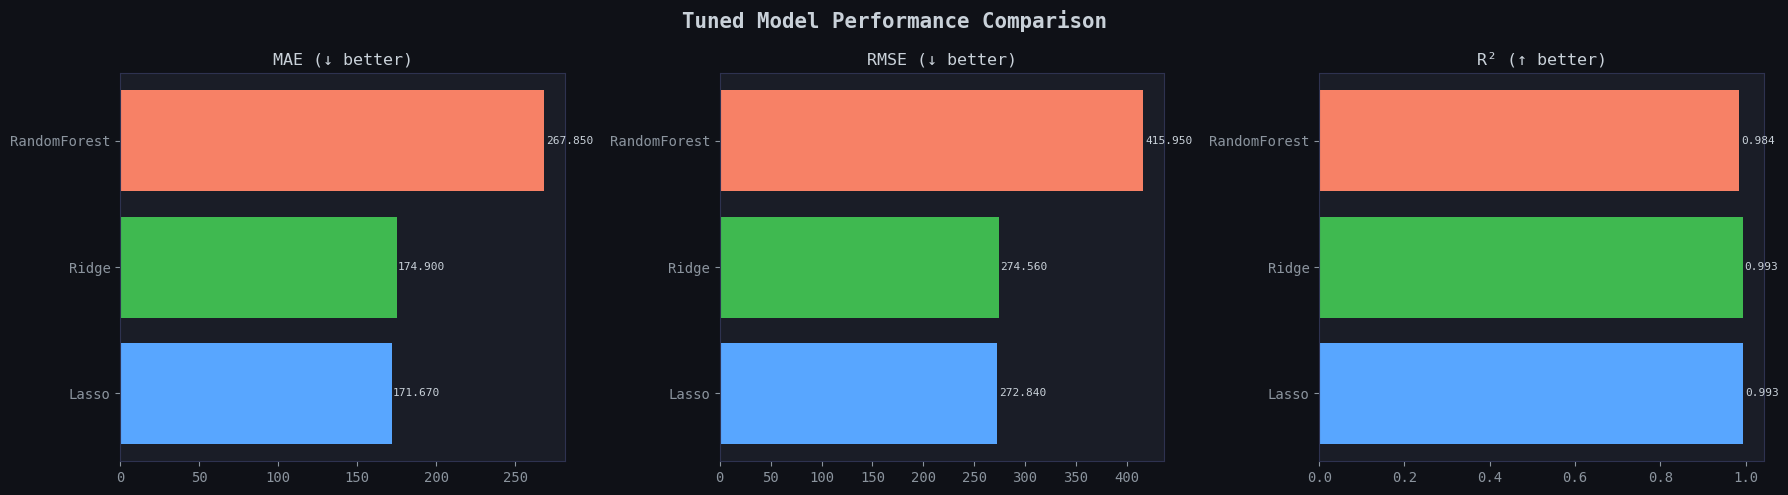

In [10]:
# Radar Chart: Model Comparison
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(['MAE', 'RMSE', 'R²']):
    asc = metric != 'R²'
    sorted_m = metrics_df.sort_values(metric, ascending=asc)
    colors = [PALETTE[j % len(PALETTE)] for j in range(len(sorted_m))]
    bars = axes[i].barh(sorted_m['Model'], sorted_m[metric], color=colors, edgecolor='none')
    axes[i].set_title(f'{metric} (↓ better)' if asc else f'{metric} (↑ better)', fontsize=12)
    for bar, val in zip(bars, sorted_m[metric]):
        axes[i].text(bar.get_width() * 1.005, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=8)

fig.suptitle('Tuned Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/14_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 : Prediction vs Actual

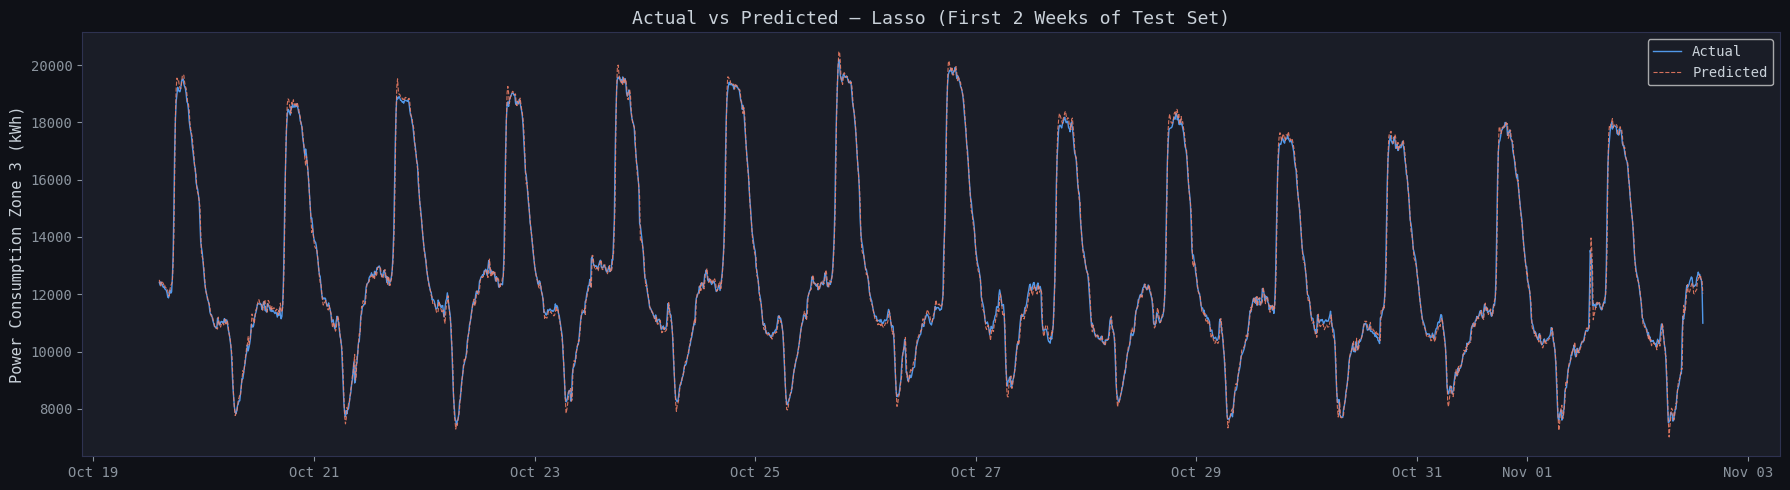

In [11]:
# Time-Series: Predicted vs Actual (sample 2 weeks) 
sample = eval_df.iloc[:2016]  # First 2 weeks of test set

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sample['Datetime'], sample['Actual'],    color='#58a6ff', linewidth=1,   label='Actual',    alpha=0.9)
ax.plot(sample['Datetime'], sample['Predicted'], color='#f78166', linewidth=0.8, label='Predicted', alpha=0.85, linestyle='--')
ax.set_title(f'Actual vs Predicted — {best_name} (First 2 Weeks of Test Set)', fontsize=13)
ax.set_ylabel('Power Consumption Zone 3 (kWh)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.tight_layout()
plt.savefig('plots/15_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

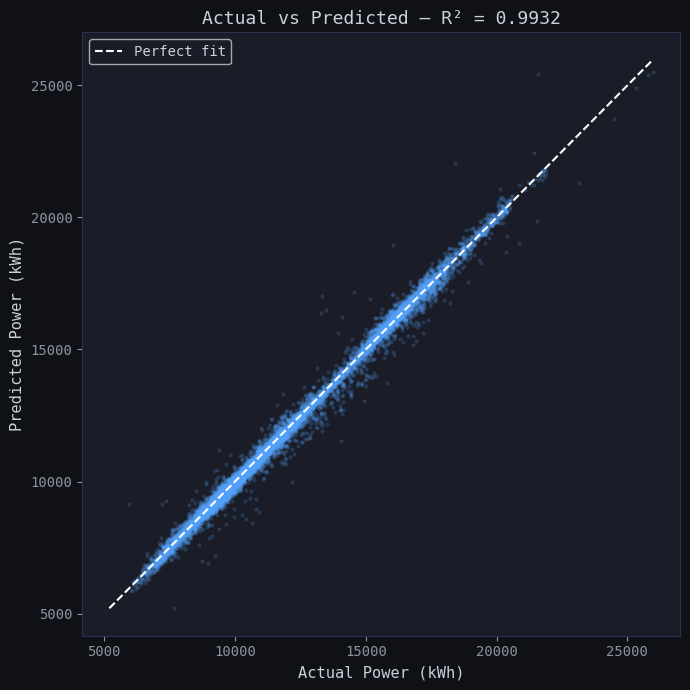

In [12]:
# Scatter: Actual vs Predicted 
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(eval_df['Actual'], eval_df['Predicted'],
           alpha=0.15, s=4, color='#58a6ff')
lims = [min(eval_df[['Actual','Predicted']].min()), max(eval_df[['Actual','Predicted']].max())]
ax.plot(lims, lims, color='white', linewidth=1.5, linestyle='--', label='Perfect fit')
ax.set_xlabel('Actual Power (kWh)')
ax.set_ylabel('Predicted Power (kWh)')
r2 = r2_score(eval_df['Actual'], eval_df['Predicted'])
ax.set_title(f'Actual vs Predicted — R² = {r2:.4f}', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('plots/16_scatter_actual_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5 : Residual Analysis

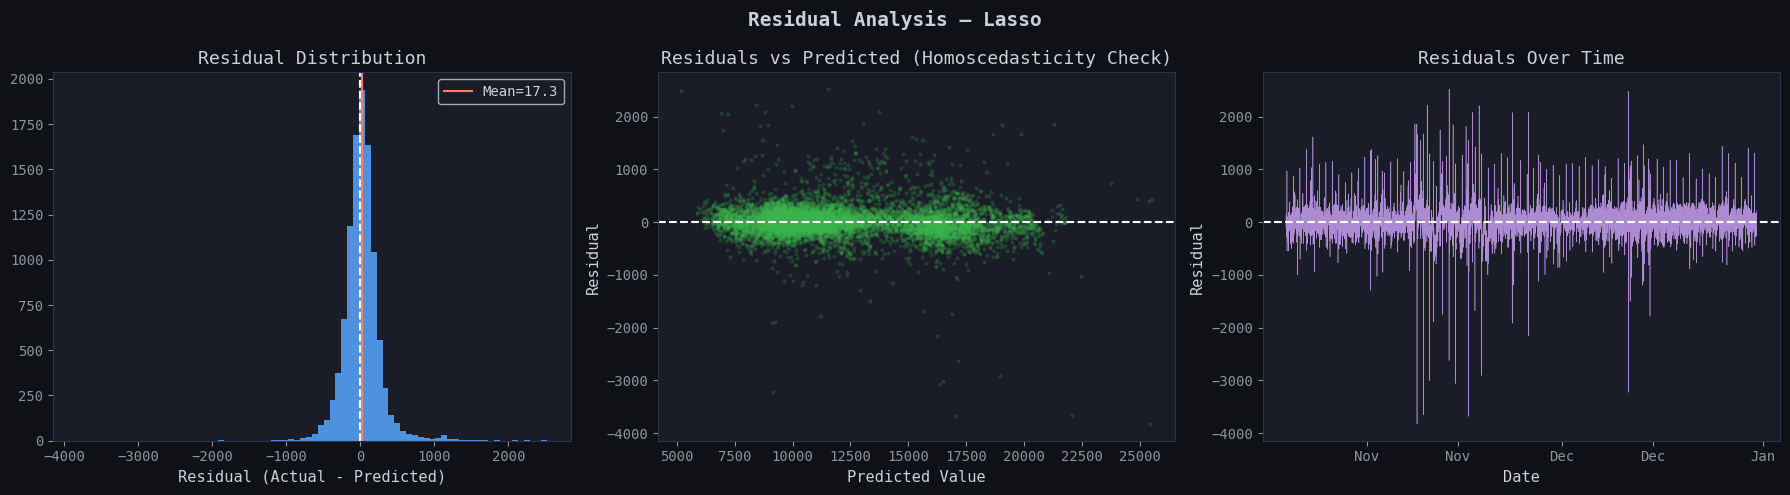

Residual mean  : 17.29 (ideally ~0)
Residual std   : 272.31
Residual skew  : -0.392


In [13]:
residuals = eval_df['Residual']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residual distribution
axes[0].hist(residuals, bins=80, color='#58a6ff', edgecolor='none', alpha=0.85)
axes[0].axvline(0, color='white', linewidth=1.5, linestyle='--')
axes[0].axvline(residuals.mean(), color='#f78166', linewidth=1.5, linestyle='-', label=f'Mean={residuals.mean():.1f}')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].legend()

# 2. Residuals vs Predicted
axes[1].scatter(eval_df['Predicted'], residuals, alpha=0.15, s=4, color='#3fb950')
axes[1].axhline(0, color='white', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted (Homoscedasticity Check)')

# 3. Residuals over time
axes[2].plot(eval_df['Datetime'], residuals, color='#d2a8ff', linewidth=0.4, alpha=0.8)
axes[2].axhline(0, color='white', linewidth=1.5, linestyle='--')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals Over Time')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

fig.suptitle(f'Residual Analysis — {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/17_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Residual mean  : {residuals.mean():.2f} (ideally ~0)')
print(f'Residual std   : {residuals.std():.2f}')
print(f'Residual skew  : {residuals.skew():.3f}')

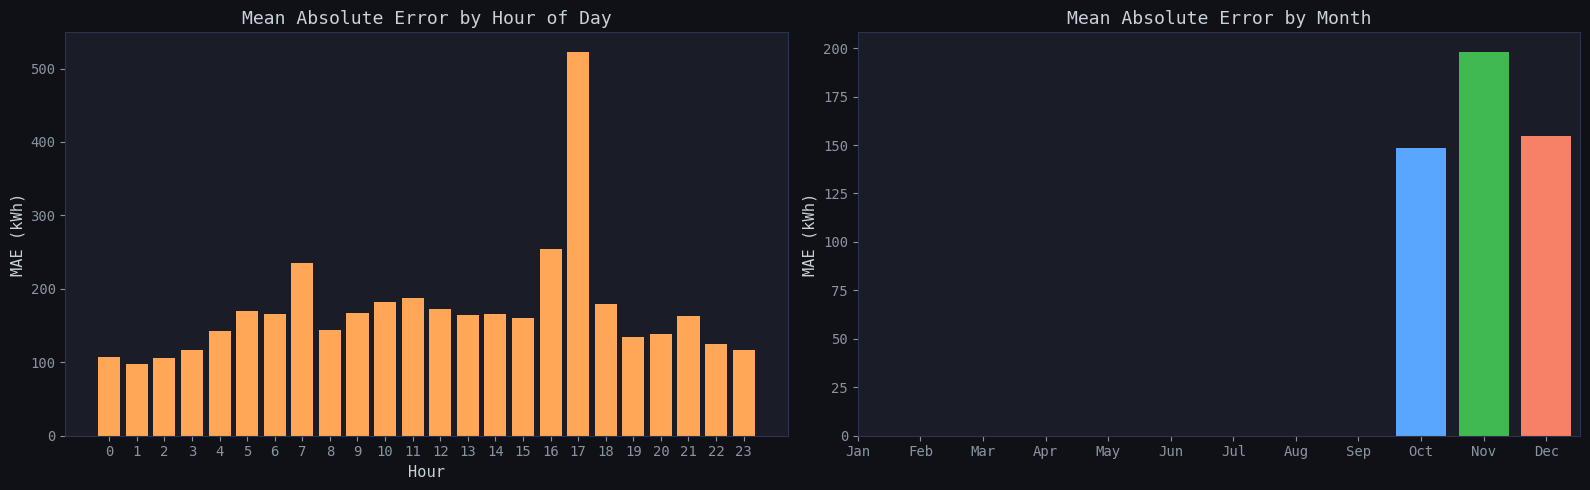

In [14]:
# Error by Hour of Day 
eval_df['Hour'] = eval_df['Datetime'].dt.hour
eval_df['Month'] = eval_df['Datetime'].dt.month
eval_df['AbsError'] = eval_df['Residual'].abs()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hourly_err = eval_df.groupby('Hour')['AbsError'].mean()
axes[0].bar(hourly_err.index, hourly_err.values, color='#ffa657', edgecolor='none')
axes[0].set_title('Mean Absolute Error by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('MAE (kWh)')
axes[0].set_xticks(range(0, 24))

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_err = eval_df.groupby('Month')['AbsError'].mean()
axes[1].bar(monthly_err.index, monthly_err.values,
            color=PALETTE * 2, edgecolor='none')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].set_title('Mean Absolute Error by Month')
axes[1].set_ylabel('MAE (kWh)')

plt.tight_layout()
plt.savefig('plots/18_error_by_time.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 : Shap Explaianability

In [17]:
# SHAP Setup
shap.initjs()

# Use TreeExplainer for tree-based models
tree_based = ['RandomForest', 'ExtraTrees', 'GradientBoosting', 'XGBoost']

# Subsample for SHAP (used in both branches)
shap_sample = X_test.sample(min(500, len(X_test)), random_state=42)

if best_name in tree_based:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(shap_sample)
else:
    background_np = shap.sample(X_train, 100, random_state=42).values
    shap_sample_np = shap_sample.values
    predict_fn = lambda x: best_model.predict(pd.DataFrame(x, columns=FEATURES))
    explainer = shap.KernelExplainer(predict_fn, background_np)
    shap_values = explainer.shap_values(shap_sample_np)

print(f'SHAP values computed for {len(shap_sample):,} test samples ')
print(f'SHAP array shape: {np.array(shap_values).shape}')

  0%|          | 0/500 [00:00<?, ?it/s]

SHAP values computed for 500 test samples 
SHAP array shape: (500, 31)


In [18]:
# Compute SHAP values on a subsample of the test set
shap_sample = X_test.sample(min(1000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(shap_sample)
print(f'SHAP values computed for {len(shap_sample):,} test samples ')
print(f'SHAP array shape: {np.array(shap_values).shape}')

  0%|          | 0/1000 [00:00<?, ?it/s]

SHAP values computed for 1,000 test samples 
SHAP array shape: (1000, 31)


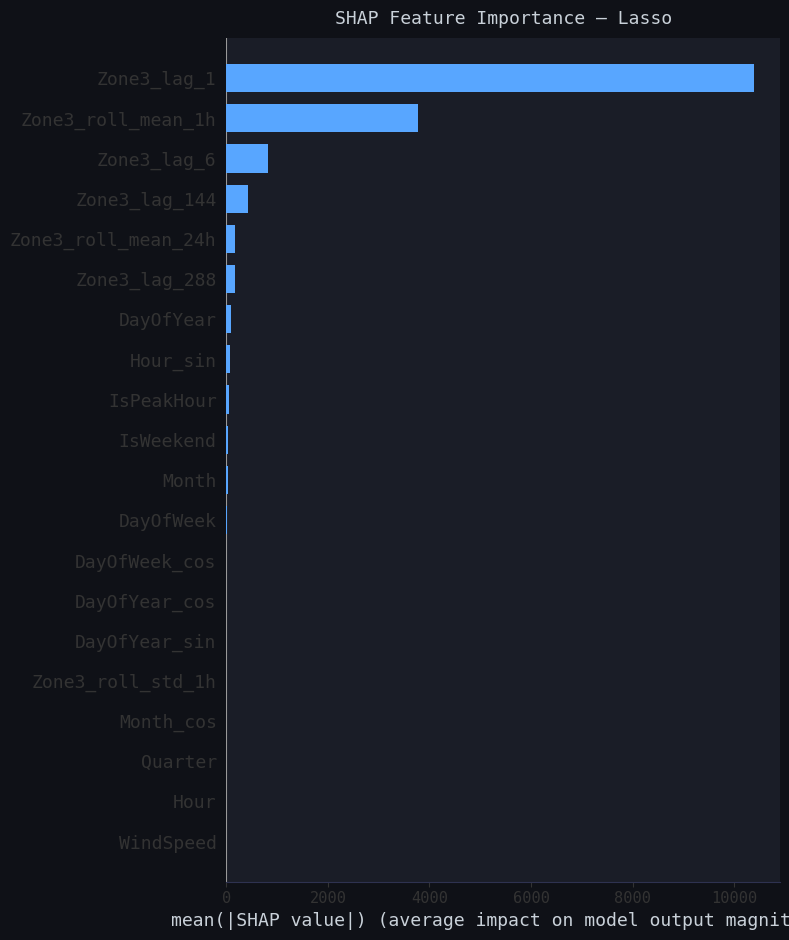

In [19]:
# SHAP Summary Bar Plot 
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, plot_type='bar',
                  feature_names=FEATURES, show=False, color='#58a6ff')
plt.title(f'SHAP Feature Importance — {best_name}', fontsize=13, pad=10)
plt.tight_layout()
plt.savefig('plots/19_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

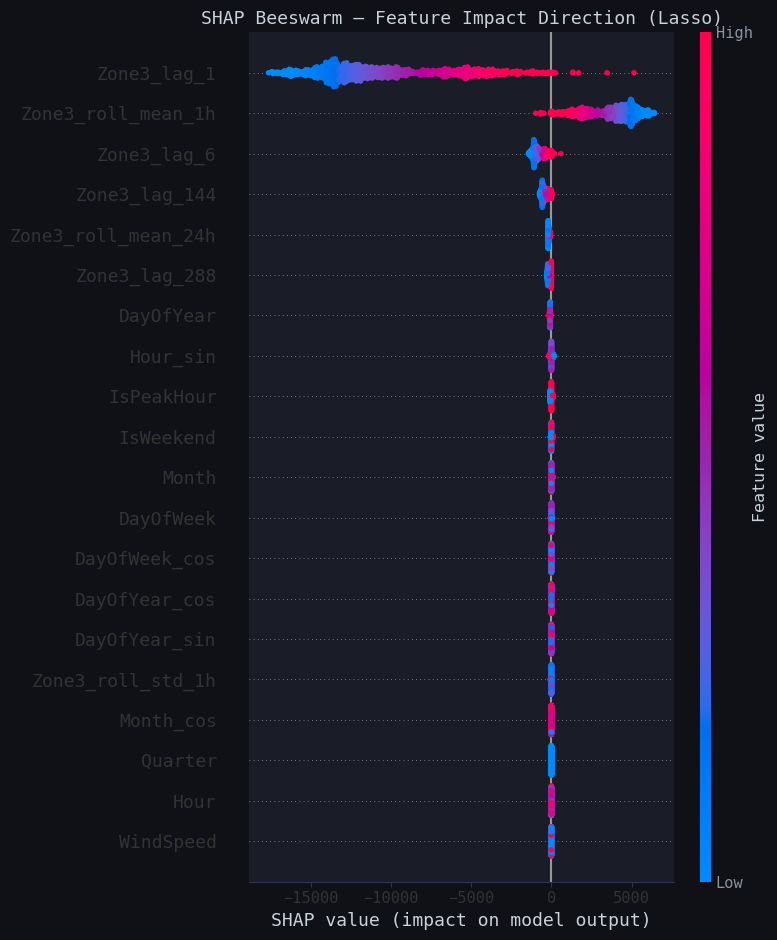

In [20]:
# SHAP Beeswarm (impact direction) 
fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_values, shap_sample,
                  feature_names=FEATURES, show=False, max_display=20)
plt.title(f'SHAP Beeswarm — Feature Impact Direction ({best_name})', fontsize=13)
plt.tight_layout()
plt.savefig('plots/20_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

Explaining peak demand prediction:
  Actual    : 25,972 kWh
  Predicted : 25,524 kWh


  0%|          | 0/1 [00:00<?, ?it/s]

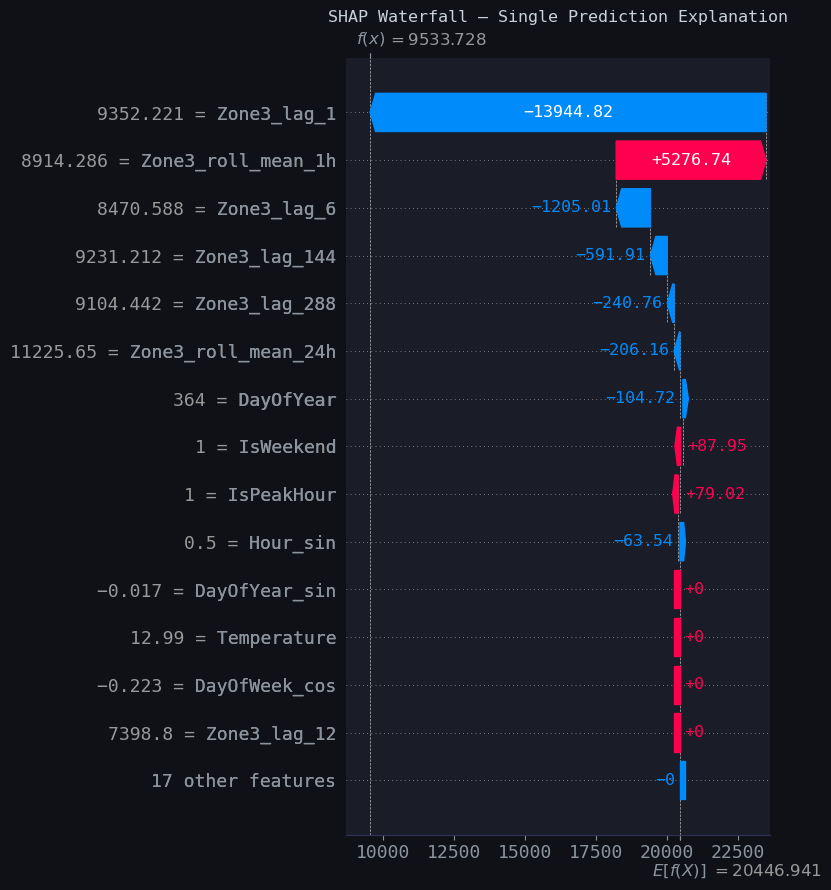

In [21]:
# SHAP Waterfall — Single Prediction Explanation 
# Explain the prediction for the highest-consumption point in test set
peak_idx = y_test.values.argmax()
peak_shap_idx = shap_sample.index.get_loc(X_test.index[peak_idx]) \
    if X_test.index[peak_idx] in shap_sample.index else 0

print(f'Explaining peak demand prediction:')
print(f'  Actual    : {y_test.values[peak_idx]:,.0f} kWh')
print(f'  Predicted : {best_model.predict(X_test.iloc[[peak_idx]])[0]:,.0f} kWh')

shap_exp = explainer(shap_sample.iloc[:1])  # Single prediction
fig = plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_exp[0], show=False, max_display=15)
plt.title(f'SHAP Waterfall — Single Prediction Explanation', fontsize=12)
plt.tight_layout()
plt.savefig('plots/21_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7 : Permutation Importance

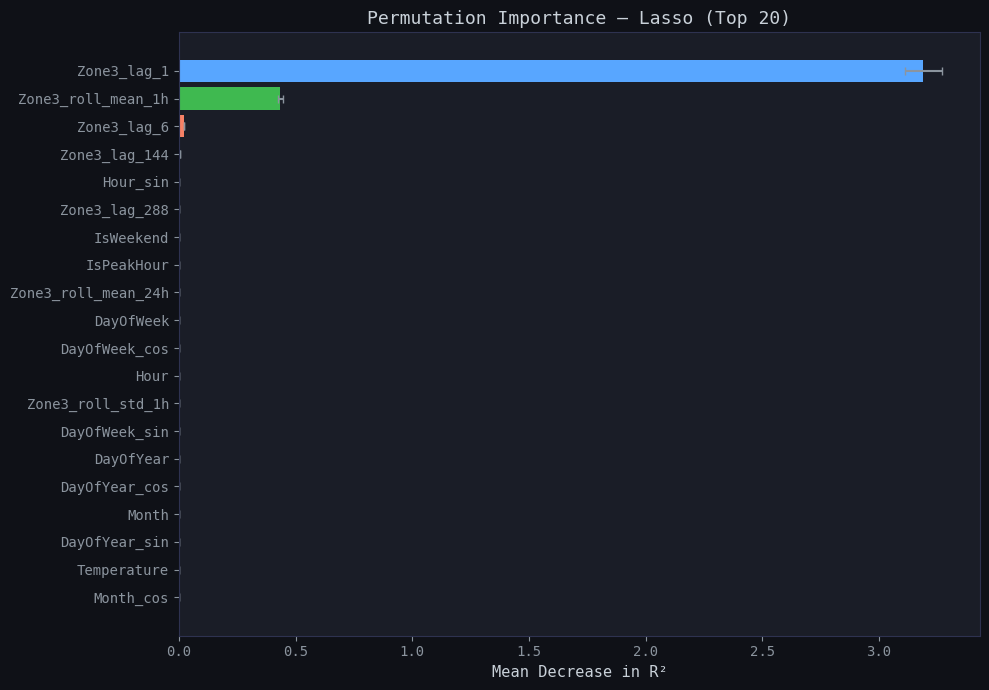

In [22]:
# Permutation Importance 
# Uses a subsample for speed
perm_sample = X_test.sample(min(2000, len(X_test)), random_state=42)
perm_y      = y_test.loc[perm_sample.index]

perm = permutation_importance(best_model, perm_sample, perm_y,
                               n_repeats=10, random_state=42, n_jobs=-1)

perm_df = pd.DataFrame({
    'Feature'    : FEATURES,
    'Importance' : perm.importances_mean,
    'Std'        : perm.importances_std,
}).sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(perm_df))]
ax.barh(perm_df['Feature'][::-1], perm_df['Importance'][::-1],
         xerr=perm_df['Std'][::-1], color=colors[::-1],
         edgecolor='none', capsize=3, ecolor='#8b949e')
ax.set_title(f'Permutation Importance — {best_name} (Top 20)', fontsize=13)
ax.set_xlabel('Mean Decrease in R²')
plt.tight_layout()
plt.savefig('plots/22_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8 : Seasonal Performance Breakdown

In [23]:
# Performance per Season 
eval_df['Season'] = eval_df['Month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring',  4:'Spring', 5:'Spring',
    6:'Summer',  7:'Summer', 8:'Summer',
    9:'Autumn',  10:'Autumn', 11:'Autumn'
})

In [24]:
season_metrics = []
for season, grp in eval_df.groupby('Season'):
    mae  = mean_absolute_error(grp['Actual'], grp['Predicted'])
    rmse = np.sqrt(mean_squared_error(grp['Actual'], grp['Predicted']))
    r2   = r2_score(grp['Actual'], grp['Predicted'])
    season_metrics.append({'Season': season, 'MAE': round(mae,2),
                            'RMSE': round(rmse,2), 'R²': round(r2,4)})

In [25]:
season_df = pd.DataFrame(season_metrics)
print('=== SEASONAL PERFORMANCE ===')
print(season_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
season_order = ['Winter','Spring','Summer','Autumn']
season_colors = ['#79c0ff','#3fb950','#ffa657','#d2a8ff']

=== SEASONAL PERFORMANCE ===
Season    MAE   RMSE     R²
Autumn 183.67 298.86 0.9923
Winter 154.72 231.12 0.9934


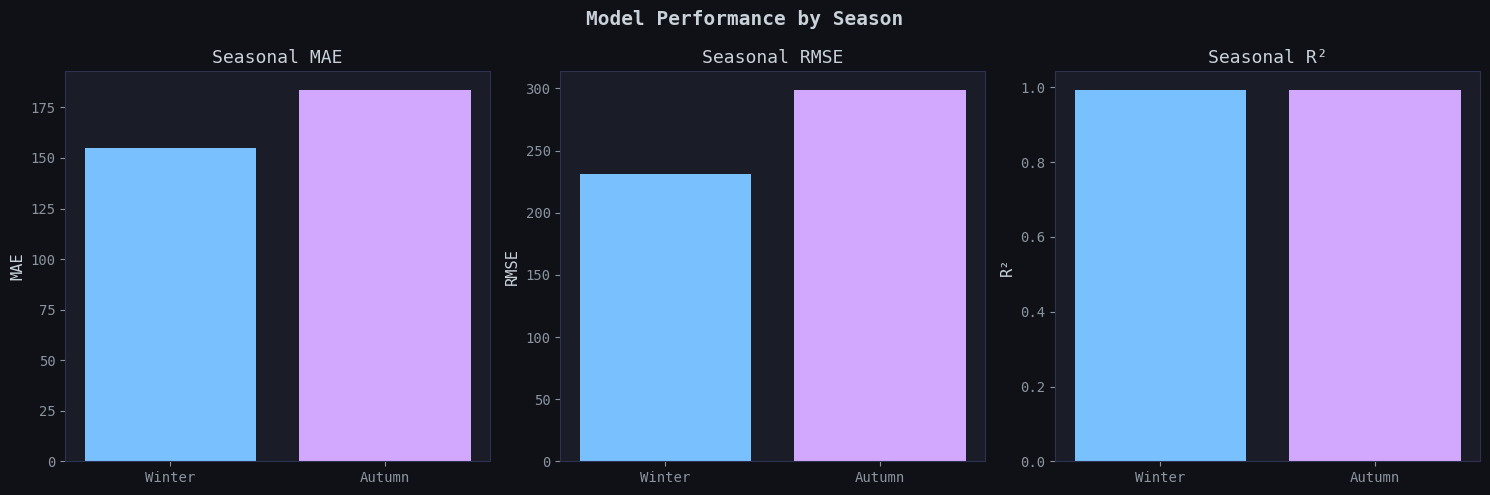

In [26]:
for i, metric in enumerate(['MAE','RMSE','R²']):
    vals = [season_df[season_df['Season'] == s][metric].values[0]
            for s in season_order if s in season_df['Season'].values]
    s_shown = [s for s in season_order if s in season_df['Season'].values]
    colors_s = [season_colors[season_order.index(s)] for s in s_shown]
    axes[i].bar(s_shown, vals, color=colors_s, edgecolor='none')
    axes[i].set_title(f'Seasonal {metric}')
    axes[i].set_ylabel(metric)

fig.suptitle('Model Performance by Season', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/23_seasonal_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9 : ROC - style Error Threshold Analysis

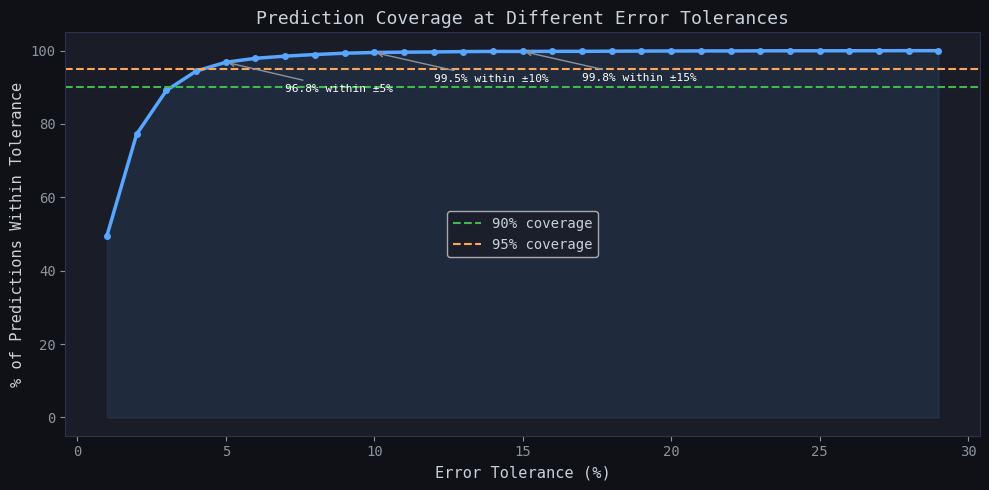

In [27]:
# What % of predictions fall within N% of actual? 
pct_errors = np.abs(eval_df['Residual'] / eval_df['Actual']) * 100
thresholds = np.arange(1, 30, 1)
within_pct = [(pct_errors <= t).mean() * 100 for t in thresholds]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, within_pct, color='#58a6ff', linewidth=2.5, marker='o', markersize=4)
ax.axhline(90, color='#3fb950', linestyle='--', linewidth=1.5, label='90% coverage')
ax.axhline(95, color='#ffa657', linestyle='--', linewidth=1.5, label='95% coverage')
ax.fill_between(thresholds, within_pct, alpha=0.1, color='#58a6ff')
ax.set_xlabel('Error Tolerance (%)')
ax.set_ylabel('% of Predictions Within Tolerance')
ax.set_title('Prediction Coverage at Different Error Tolerances', fontsize=13)
ax.legend()

# Annotate key thresholds
for t_val in [5, 10, 15]:
    cov = (pct_errors <= t_val).mean() * 100
    ax.annotate(f'{cov:.1f}% within ±{t_val}%',
                xy=(t_val, cov), xytext=(t_val + 2, cov - 8),
                fontsize=8, color='white',
                arrowprops=dict(arrowstyle='->', color='#8b949e', lw=1))

plt.tight_layout()
plt.savefig('plots/24_error_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 10 : Final Reccomendation 

In [28]:
# Print Final Summary 
best_row = metrics_df.iloc[0]
print('=' * 55)
print(f'  BEST MODEL: {best_name}')
print('=' * 55)
print(f'  MAE    : {best_row["MAE"]:,.2f} kWh')
print(f'  RMSE   : {best_row["RMSE"]:,.2f} kWh')
print(f'  R²     : {best_row["R²"]:.4f}')
print(f'  MAPE   : {best_row["MAPE %"]:.2f}%')
print('=' * 55)
print(f'  Within ±5%  : {(pct_errors <= 5).mean()*100:.1f}% of predictions')
print(f'  Within ±10% : {(pct_errors <= 10).mean()*100:.1f}% of predictions')
print('=' * 55)

  BEST MODEL: Lasso
  MAE    : 171.67 kWh
  RMSE   : 272.84 kWh
  R²     : 0.9932
  MAPE   : 1.47%
  Within ±5%  : 96.8% of predictions
  Within ±10% : 99.5% of predictions
